<a href="https://colab.research.google.com/github/Ahmad-Zainudin-Fanani/244107020051_mobile_course/blob/main/Pertemuan_2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Langkah 1: Import Library
Memanggil library yang dibutuhkan untuk pengolahan citra:
* **numpy**: Manipulasi array
* **pandas**: Analisis data
* **cv2 (OpenCV)**: Computer vision / pengolahan citra
* **skimage**: Image processing
* **PIL (Pillow)**: Manipulasi gambar
* **matplotlib**: Visualisasi dan grafik

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow # for image display
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

### Langkah 2: Membaca dan Menampilkan Gambar dari URL
Membaca gambar langsung dari URL menggunakan skimage, mengubah ukuran citra (*resize*) menjadi setengahnya, melakukan konversi format warna dari BGR ke RGB menggunakan OpenCV, serta menampilkan perbandingannya secara berdampingan.

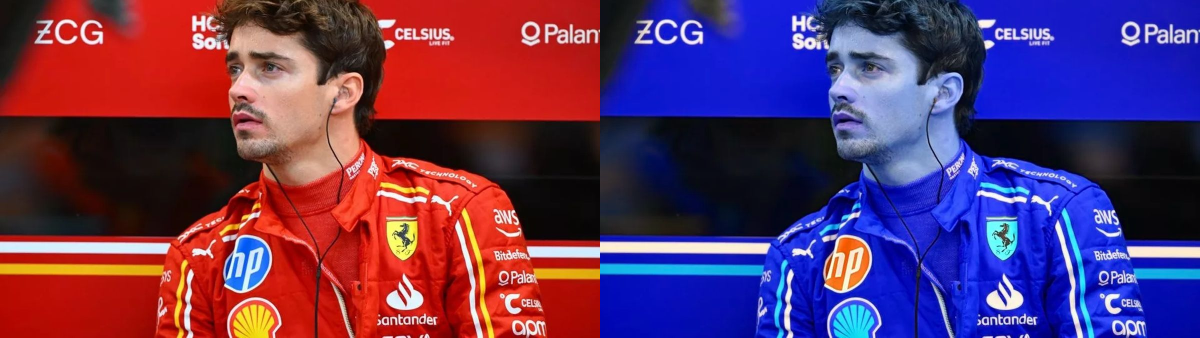

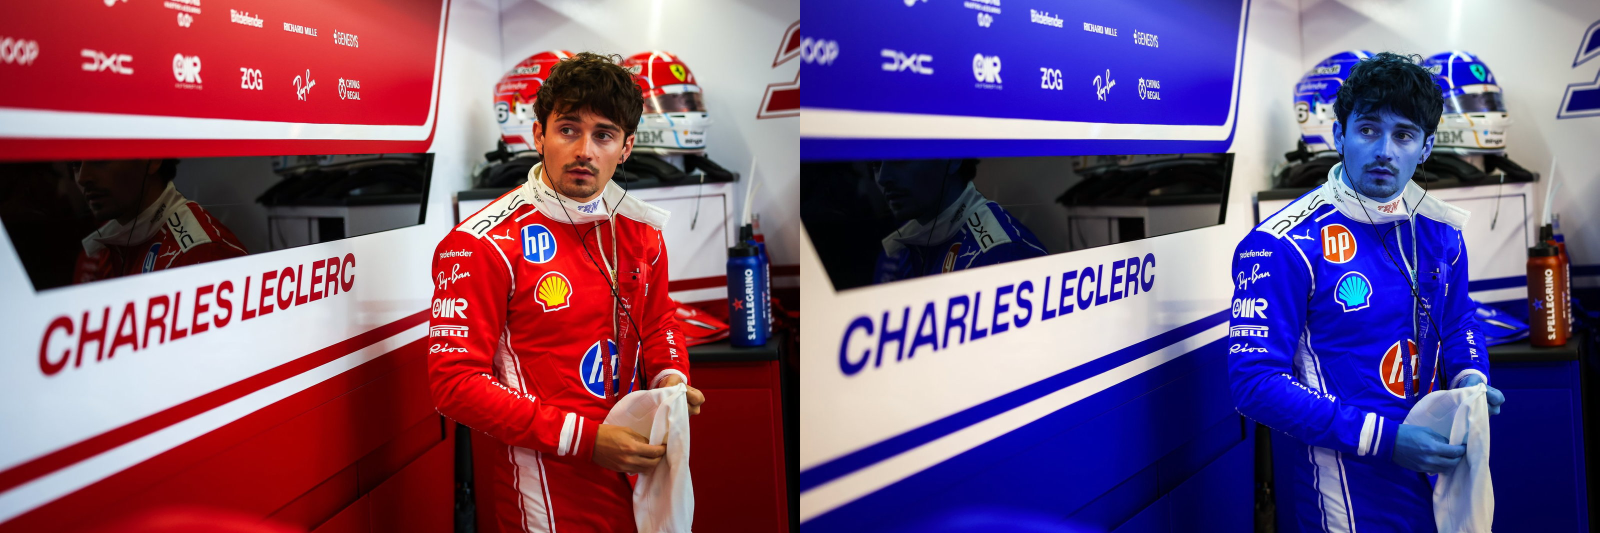

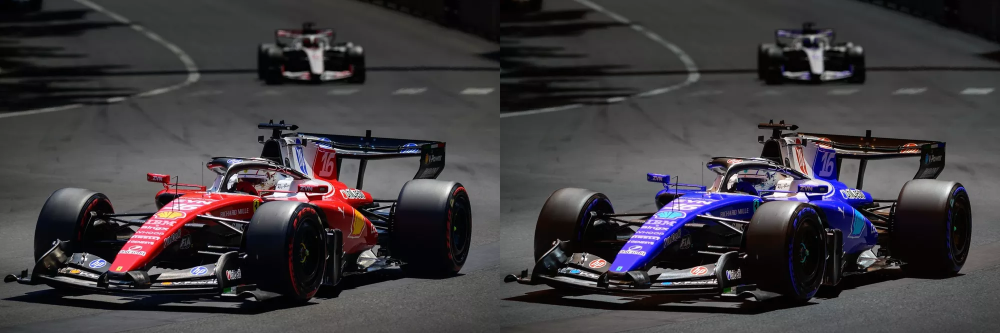

In [ ]:
import urllib.request
import numpy as np

urls = [
    "https://imgsrv2.voi.id/tYcStGenc370kAq1e1ia5y0yCgYi2n4JqCUAnY_Ou5o/auto/1200/675/sm/1/bG9jYWw6Ly8vcHVibGlzaGVycy80ODQ2MDEvMjAyNTA1MjUxNzA0LW1haW4ud2VicA.jpg",
    "https://www.crash.net/sites/default/files/2026-06/07-canada-gp-2026-sat_822894ba-c3b7-4b40-bc8a-ba8924168b2f.jpg",
    "https://cdn-2.motorsport.com/images/amp/2dE7LaLY/s1000/charles-leclerc-ferrari-2.webp"
]

headers = {'User-Agent': 'Mozilla/5.0'}

for url in urls:
    try:
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req) as resp:
            image_array = np.asarray(bytearray(resp.read()), dtype="uint8")
            image = cv.imdecode(image_array, cv.IMREAD_COLOR)

        if image is not None:
            image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)
            image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
            final_frame = cv.hconcat((image, image_2))
            cv2_imshow(final_frame)
            print('\n')
        else:
            print(f"Gagal memproses gambar dari: {url}\n")

    except Exception as e:
        print(f"Error saat mengunduh {url}: {e}\n")

### Langkah 3: Melihat Ukuran / Resolusi Citra
Mendapatkan dimensi resolusi citra (tinggi dan lebar dalam piksel) menggunakan atribut `.shape` dari array NumPy, lalu menampilkannya bersama gambarnya.

resolusi image: tinggi x lebar =  333  x  500


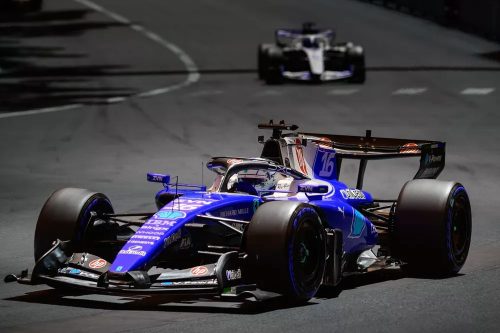

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar = ", tinggi, " x ", lebar)
cv2_imshow(image_2)

### Langkah 4: Mengakses Piksel dan Menggambar Garis Horizontal
Mengakses nilai piksel secara langsung dengan manipulasi indeks matriks untuk membuat garis horizontal berwarna putih `[255, 255, 255]` tepat di tengah gambar.

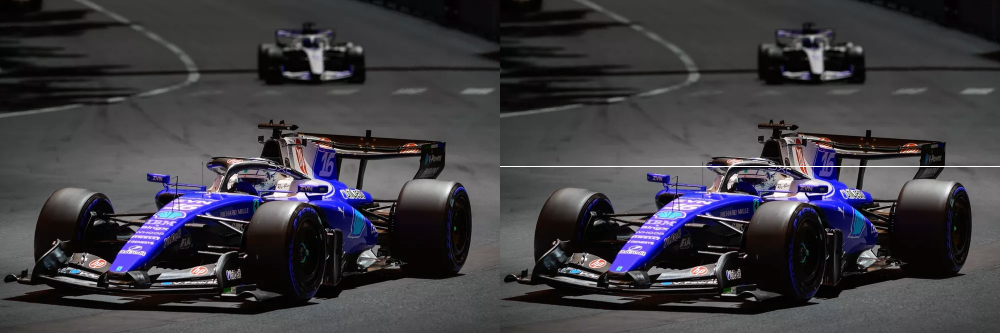

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# membuat garis horizontal ditengah image
for y in range(lebar):
    image_3[int((tinggi)/2), y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

**1. Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan menggunakan Google Colab?**

**Jawaban:**  
Eksekusi kode dilakukan di Google Colab karena berbasis *cloud*, sehingga tidak memerlukan instalasi aplikasi maupun pustaka (*library*) tambahan di komputer lokal. Format *notebook*-nya memudahkan penggabungan penjelasan teks, kode program, dan penampilan hasil citra secara langsung dalam satu tempat. Selain itu, Google Colab terintegrasi langsung dengan GitHub dan Google Drive, yang mempermudah proses penyimpanan dan pengumpulan tugas.

---

**2. Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke delapan? Apakah semua library tersebut harus digunakan dalam praktikum sesi ini?**

**Jawaban:**  
Pada praktikum langkah ke-8, library yang digunakan memiliki fungsi spesifik: `cv2` (OpenCV) berfungsi untuk membaca, memanipulasi nilai matriks piksel, dan memproses citra; `cv2_imshow` berfungsi untuk menampilkan citra langsung pada cell Google Colab sebagai pengganti `cv2.imshow`; sedangkan `numpy` berfungsi untuk menangani operasi array multidimensi pada data citra.

Tidak semua library yang diimpor mutlak harus digunakan secara eksplisit dalam setiap blok kode, namun pada sesi praktikum ini ketiga komponen tersebut saling berkaitan erat karena citra di OpenCV direpresentasikan sebagai array NumPy dan `cv2_imshow` dibutuhkan untuk menampilkan visualisasinya di Colab.

---

**3. Perhatikan potongan kode program berikut :**

```python
#membuat garis horizontal ditengah image
for y in range (lebar):
    image_3[int((tinggi)/2),y] = [255,255,255]
```

**Apakah kegunaan kode [255,255,255] ? Jelaskan!**

**Jawaban:**  
Kode `[255, 255, 255]` berfungsi untuk menetapkan warna putih pada piksel yang dituju. Pada pustaka OpenCV, citra berwarna menggunakan format ruang warna BGR (Blue, Green, Red). Angka 255 merepresentasikan nilai intensitas maksimum (8-bit) untuk masing-masing kanal warna—biru (255), hijau (255), dan merah (255)—sehingga kombinasi ketiga kanal dengan nilai maksimal tersebut menghasilkan warna putih.

---

**4. Jelaskan keterkaitan antara pixel dan juga resolusi gambar yang tinggi ataupun rendah!**

**Jawaban:**  
Piksel adalah unit terkecil penyusun citra digital yang membawa informasi warna, sedangkan resolusi gambar menunjukkan jumlah total kepadatan piksel (lebar × tinggi) yang membentuk citra tersebut. Keterkaitannya: resolusi tinggi memiliki jumlah piksel yang lebih banyak dan rapat, sehingga detail citra tampak tajam, jernih, dan tidak mudah pecah saat diperbesar. Sebaliknya, resolusi rendah memiliki jumlah piksel yang sedikit, sehingga detail tampak kasar, buram, dan mudah mengalami efek kotak-kotak (*pixelated*) ketika diperbesar.

### TUGAS PRAKTIKUM D2
1. Lakukan langkah-langkah praktikum seperti diatas
2. Buat garis vertikal dan garis menyilang diagonal pada image keluaran


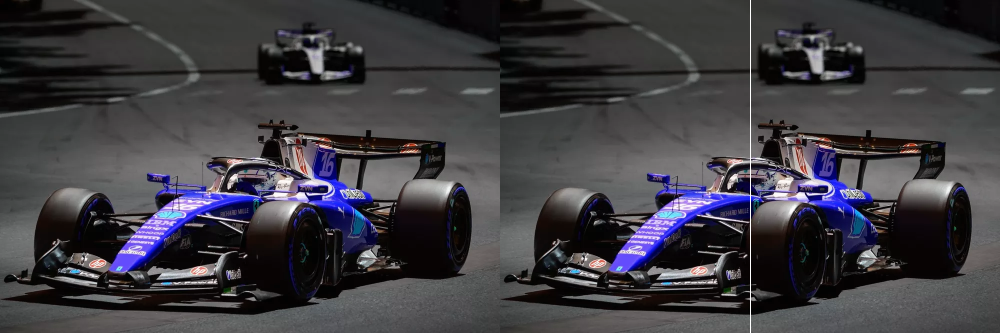

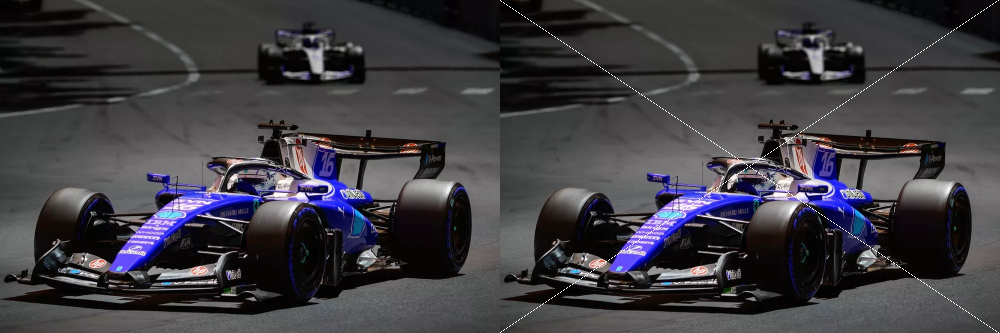

In [ ]:
# 1. Garis Vertikal (Tepat di tengah)
img_vertikal = image_2.copy()
garis_x = int(lebar / 2)  # <-- diubah ke titik tengah (50% dari lebar)

for x in range(tinggi):
    img_vertikal[x, garis_x] = [255, 255, 255]

final_vertikal = cv.hconcat((image_2, img_vertikal))
cv2_imshow(final_vertikal)
print('\n')

# 2. Garis Diagonal Menyilang (Bentuk X)
img_diagonal = image_2.copy()

for x in range(tinggi):
    y1 = int(x * (lebar / tinggi))
    if 0 <= y1 < lebar:
        img_diagonal[x, y1] = [255, 255, 255]

    y2 = int((tinggi - 1 - x) * (lebar / tinggi))
    if 0 <= y2 < lebar:
        img_diagonal[x, y2] = [255, 255, 255]

final_diagonal = cv.hconcat((image_2, img_diagonal))
cv2_imshow(final_diagonal)

3. Buat garis horisontal berwarna putih dibagian tengah gambar dengan panjang tertentu

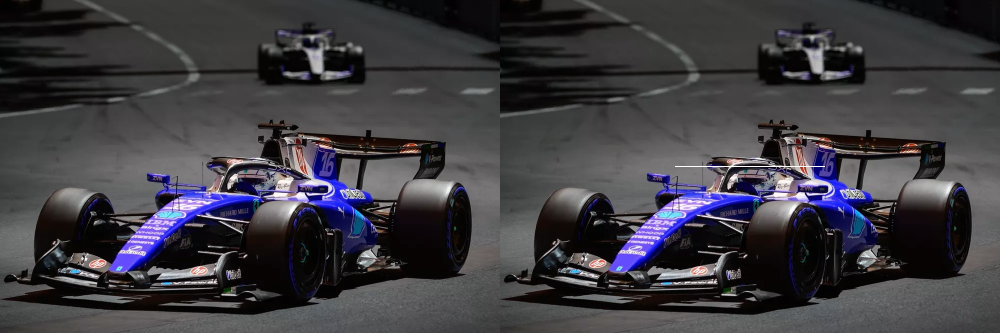

In [ ]:
img_panjang_tertentu = image_2.copy()
tengah_y = int(tinggi / 2)

# Batasan rentang koordinat garis horizontal
start_x = int(lebar * 0.35)
end_x = int(lebar * 0.65)

for y in range(start_x, end_x):
    img_panjang_tertentu[tengah_y, y] = [255, 255, 255]

final_tertentu = cv.hconcat((image_2, img_panjang_tertentu))
cv2_imshow(final_tertentu)

4. Buat kotak menggunakan kumpulan pixel warna putih di sembarang tempat dalam gambar


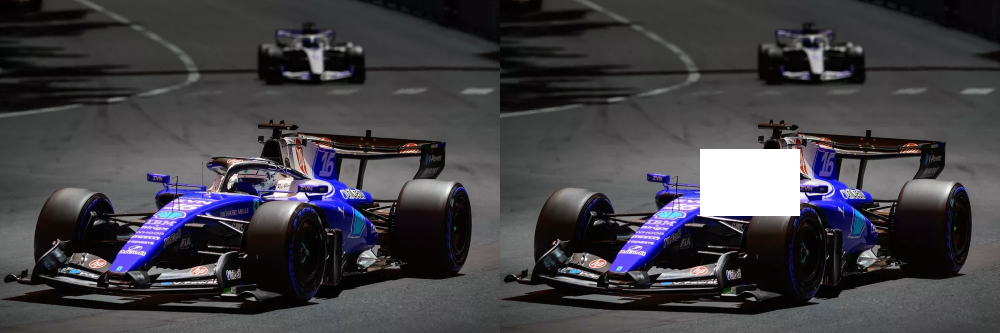

In [ ]:
img_kotak = image_2.copy()

# Menentukan batas koordinat kotak putih
y_start = int(tinggi * 0.45)
y_end = int(tinggi * 0.65)
x_start = int(lebar * 0.40)
x_end = int(lebar * 0.60)

# Mengisi area kotak dengan piksel warna putih
img_kotak[y_start:y_end, x_start:x_end] = [255, 255, 255]

final_kotak = cv.hconcat((image_2, img_kotak))
cv2_imshow(final_kotak)